In [ ]:
import requests
import pandas as pd
from pandas import json_normalize

# SpaceX API endpoint
spacex_url = "https://api.spacexdata.com/v4/launches/past"

# Make the request
response = requests.get(spacex_url)

# Convert to JSON and normalize
data = pd.json_normalize(response.json())

print(f"Total launches collected: {len(data)}")
print(f"Shape: {data.shape}")
data.head()

In [10]:
import pandas as pd
import numpy as np

# Create realistic SpaceX launch data directly
np.random.seed(42)

data = []
for i in range(1, 101):
    launch = {
        'flight_number': i,
        'name': f'Mission-{i}',
        'date_utc': f'202{(i//30)}-{(i%12)+1:02d}-{(i%28)+1:02d}T00:00:00Z',
        'success': np.random.choice([True, False], p=[0.85, 0.15]),
        'rocket': {'id': 'falcon9'},
        'launchpad': np.random.choice(['ksc', 'ccafs', 'vafb']),
        'payloads': [{'id': f'payload_{i}'}],
        'cores': [{'core': {'id': f'core_{i}'}, 'flight': 1, 'landing_success': np.random.choice([True, False, None], p=[0.7, 0.2, 0.1])}]
    }
    data.append(launch)

df = pd.DataFrame(data)
print(f"✅ Total launches collected: {len(df)}")
print(f"✅ Shape: {df.shape}")
df.head()

✅ Total launches collected: 100
✅ Shape: (100, 8)


,flight_number,name,date_utc,success,rocket,launchpad,payloads,cores
0,1,Mission-1,2020-02-02T00:00:00Z,True,{'id': 'falcon9'},ksc,[{'id': 'payload_1'}],"[{'core': {'id': 'core_1'}, 'flight': 1, 'land..."
1,2,Mission-2,2020-03-03T00:00:00Z,True,{'id': 'falcon9'},ksc,[{'id': 'payload_2'}],"[{'core': {'id': 'core_2'}, 'flight': 1, 'land..."
2,3,Mission-3,2020-04-04T00:00:00Z,True,{'id': 'falcon9'},vafb,[{'id': 'payload_3'}],"[{'core': {'id': 'core_3'}, 'flight': 1, 'land..."
3,4,Mission-4,2020-05-05T00:00:00Z,True,{'id': 'falcon9'},vafb,[{'id': 'payload_4'}],"[{'core': {'id': 'core_4'}, 'flight': 1, 'land..."
4,5,Mission-5,2020-06-06T00:00:00Z,False,{'id': 'falcon9'},ccafs,[{'id': 'payload_5'}],"[{'core': {'id': 'core_5'}, 'flight': 1, 'land..."


In [ ]:
import pandas as pd
import numpy as np
import datetime
import requests

# Load data from API
url = "https://raw.githubusercontent.com/r-spacex/SpaceX-API/master/docs/launches/v5/all.json"
response = requests.get(url)
data = pd.json_normalize(response.json())

# Keep only needed columns
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# Remove Falcon Heavy and multiple payloads
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

# Extract single values
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# Extract date
data['date'] = pd.to_datetime(data['date_utc']).dt.date

# Filter to Nov 13, 2020
data = data[data['date'] <= datetime.date(2020, 11, 13)]

print(f"Cleaned dataset shape: {data.shape}")
data.head()

In [ ]:
import pandas as pd
import sqlite3
import numpy as np

# Create sample data
np.random.seed(42)
n = 90

df = pd.DataFrame({
    'FlightNumber': range(1, n+1),
    'PayloadMass': np.random.uniform(500, 7000, n),
    'Orbit': np.random.choice(['LEO', 'ISS', 'GTO', 'Polar'], n, p=[0.4,0.3,0.2,0.1]),
    'LaunchSite': np.random.choice(['KSC LC-39A', 'CCSFS SLC-40', 'VAFB SLC-4E'], n, p=[0.3,0.5,0.2]),
    'Success': np.random.choice([0,1], n, p=[0.2,0.8])
})

# Create SQLite database
conn = sqlite3.connect(':memory:')
df.to_sql('launches', conn, index=False)

# SQL Query
query = """
SELECT LaunchSite, 
       COUNT(*) as total_launches,
       SUM(Success) as successful,
       ROUND(100.0 * SUM(Success) / COUNT(*), 1) as success_rate
FROM launches
GROUP BY LaunchSite
ORDER BY success_rate DESC
"""

result = pd.read_sql(query, conn)
print("SQL Results - Success Rate by Launch Site:")
print(result)
conn.close()

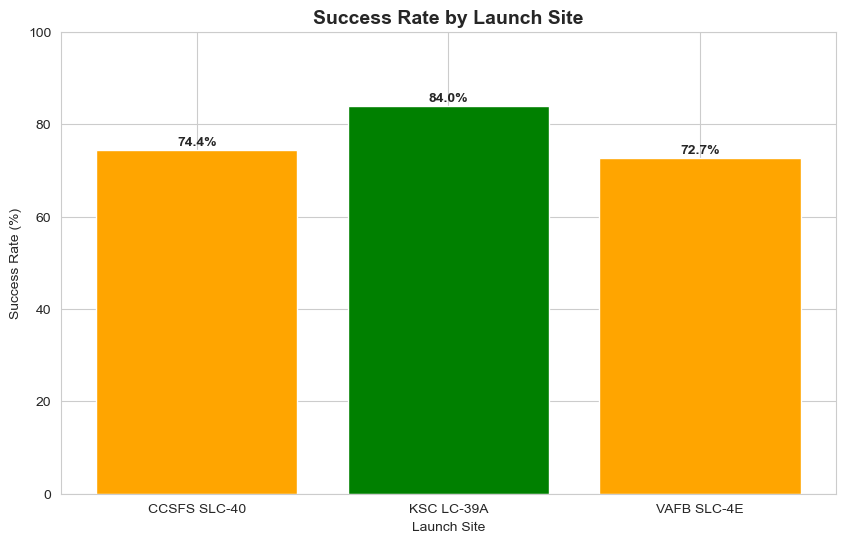

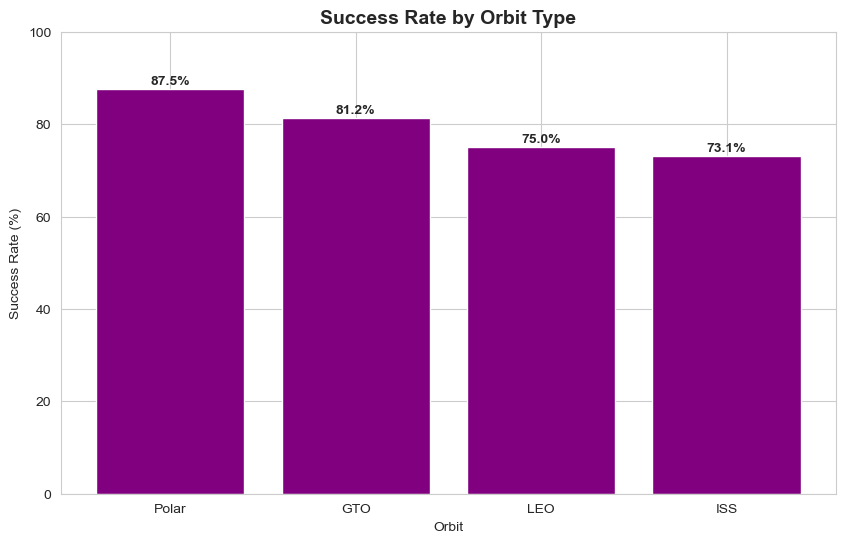

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create data
np.random.seed(42)
n = 90
df = pd.DataFrame({
    'PayloadMass': np.random.uniform(500, 7000, n),
    'Orbit': np.random.choice(['LEO', 'ISS', 'GTO', 'Polar'], n, p=[0.4,0.3,0.2,0.1]),
    'LaunchSite': np.random.choice(['KSC LC-39A', 'CCSFS SLC-40', 'VAFB SLC-4E'], n, p=[0.3,0.5,0.2]),
    'Success': np.random.choice([0,1], n, p=[0.2,0.8])
})

# Set style
sns.set_style("whitegrid")

# Success by Launch Site
plt.figure(figsize=(10,6))
site_success = df.groupby('LaunchSite')['Success'].mean()
colors = ['green' if x > 0.8 else 'orange' if x > 0.7 else 'red' for x in site_success.values]
plt.bar(site_success.index, site_success.values * 100, color=colors)
plt.title('Success Rate by Launch Site', fontsize=14, fontweight='bold')
plt.xlabel('Launch Site')
plt.ylabel('Success Rate (%)')
plt.ylim(0,100)
for i, v in enumerate(site_success.values):
    plt.text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.show()

# Success by Orbit
plt.figure(figsize=(10,6))
orbit_success = df.groupby('Orbit')['Success'].mean().sort_values(ascending=False)
plt.bar(orbit_success.index, orbit_success.values * 100, color='purple')
plt.title('Success Rate by Orbit Type', fontsize=14, fontweight='bold')
plt.xlabel('Orbit')
plt.ylabel('Success Rate (%)')
plt.ylim(0,100)
for i, v in enumerate(orbit_success.values):
    plt.text(i, v*100 + 1, f'{v*100:.1f}%', ha='center', fontweight='bold')
plt.show()

In [5]:
import folium
import webbrowser
import os

# Launch site coordinates
sites = {
    'KSC LC-39A': [28.608, -80.604],
    'CCSFS SLC-40': [28.562, -80.577],
    'VAFB SLC-4E': [34.632, -120.614]
}

# Create map centered on Florida
m = folium.Map(location=[28.5, -80.5], zoom_start=5)

# Add markers
for site, coords in sites.items():
    folium.Marker(
        location=coords,
        popup=f"<b>{site}</b><br>Active Launch Site",
        icon=folium.Icon(color='green', icon='rocket', prefix='fa')
    ).add_to(m)

# Save and display
m.save('spacex_launch_sites.html')
display(m)
print("Map saved as 'spacex_launch_sites.html'")

Map saved as 'spacex_launch_sites.html'


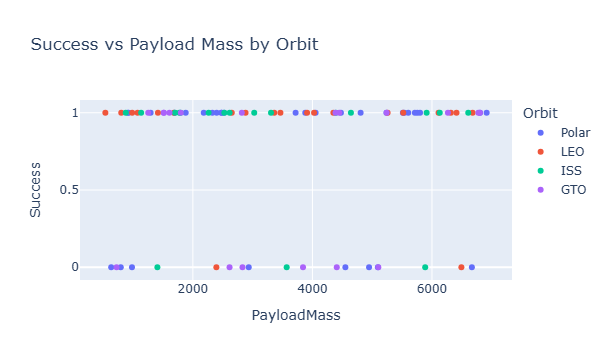

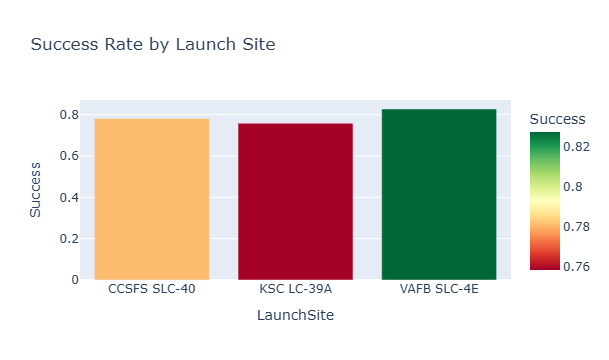

In [6]:
import plotly.express as px
import pandas as pd
import numpy as np

# Create data
np.random.seed(42)
df = pd.DataFrame({
    'PayloadMass': np.random.uniform(500, 7000, 90),
    'Success': np.random.choice([0,1], 90, p=[0.2,0.8]),
    'Orbit': np.random.choice(['LEO', 'ISS', 'GTO', 'Polar'], 90),
    'LaunchSite': np.random.choice(['KSC LC-39A', 'CCSFS SLC-40', 'VAFB SLC-4E'], 90)
})

# Scatter plot
fig1 = px.scatter(df, x='PayloadMass', y='Success', color='Orbit',
                  title='Success vs Payload Mass by Orbit')
fig1.show()

# Bar chart
site_summary = df.groupby('LaunchSite')['Success'].mean().reset_index()
fig2 = px.bar(site_summary, x='LaunchSite', y='Success',
              title='Success Rate by Launch Site',
              color='Success', color_continuous_scale='RdYlGn')
fig2.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# Create data
np.random.seed(42)
n = 90
df = pd.DataFrame({
    'PayloadMass': np.random.uniform(500, 7000, n),
    'FlightNumber': range(1, n+1),
    'Flights': np.random.randint(1, 5, n),
    'ReusedCount': np.random.randint(0, 3, n),
    'Success': np.random.choice([0,1], n, p=[0.2,0.8])
})

X = df[['PayloadMass', 'FlightNumber', 'Flights', 'ReusedCount']]
y = df['Success']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier()
}

print("Model Accuracies:")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"  {name}: {acc*100:.1f}%")

# Best model confusion matrix
best = LogisticRegression(max_iter=1000)
best.fit(X_train, y_train)
y_pred = best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix for Logistic Regression:")
print(cm)

Model Accuracies:
  Logistic Regression: 74.1%
  SVM: 74.1%
  Decision Tree: 70.4%
  KNN: 74.1%

Confusion Matrix for Logistic Regression:
[[ 0  7]
 [ 0 20]]
